# Visualize Reconstructions
 
 This tutorial focuses on looking at SWC reconstructions. Before changing or measuring a reconstruction, it helps to make a clear picture of what is in the file.
 
 You will create simple views, change the projection, show node IDs, and view several reconstructions together.

## Workflow
 
 ```text
 sample SWC files
       |
       v
 create a first picture
       |
       v
 change the projection
       |
       v
 show node IDs
       |
       v
 view several reconstructions together
 ```

## Reading the view commands

The `view` action creates an image from one or more SWC files.

A view command usually has this structure:

```text
swc view input-file options
```

| Part | Meaning |
| --- | --- |
| `swc view` | create a picture from an SWC file |
| `-o output/file.png` | save the picture here |
| `-j xy`, `-j yz`, `-j xz` | choose the projection plane |
| `-p 3` | show only one point type, here dendrites |
| `-m 5 9` | mark selected node IDs |
| `-b node-ids` | show selected branch sections |
| `-g` | show a dendrogram |
| `--show-id` | show node ID numbers on the picture |
| `-c cells` | color each reconstruction separately |
| `-c shadow` | compare files by drawing later files as shadows |
| `--scale 100` | add a 100-unit scale bar |
| `--no-axes` | hide the axes for a cleaner figure |
| `-t "title"` | add a title |

## Command helper

Run this cell once before the tutorial commands. It creates `shell_cmd()`, a small notebook helper that runs terminal commands, shows their output, and displays images when a command creates one.

In [1]:
import subprocess
from pathlib import Path

from IPython.display import Image, display


def shell_cmd(command, image=None):
    print("Executed command:")
    print(command)
    result = subprocess.run(
        command,
        shell=True,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
        text=True,
    )
    output = result.stdout.rstrip()
    print("\nOutput:")
    print(output if output else "(empty)")

    if image is not None and Path(image).exists():
        display(Image(filename=image))


## Copy sample files

Use one larger reconstruction for the first views, one small reconstruction for node IDs, and two reconstructions for comparison.

In [2]:
shell_cmd("cp -v ../tests/data/pass_nmo_1.swc data/")
shell_cmd("cp -v ../tests/data/pass_simple_branch.swc data/")
shell_cmd("cp -v ../tests/data/pass_mouselight_1.swc ../tests/data/pass_mouselight_2.swc data/")

Executed command:
cp -v ../tests/data/pass_nmo_1.swc data/

Output:
'../tests/data/pass_nmo_1.swc' -> 'data/pass_nmo_1.swc'
Executed command:
cp -v ../tests/data/pass_simple_branch.swc data/

Output:
'../tests/data/pass_simple_branch.swc' -> 'data/pass_simple_branch.swc'
Executed command:
cp -v ../tests/data/pass_mouselight_1.swc ../tests/data/pass_mouselight_2.swc data/

Output:
'../tests/data/pass_mouselight_1.swc' -> 'data/pass_mouselight_1.swc'
'../tests/data/pass_mouselight_2.swc' -> 'data/pass_mouselight_2.swc'


## Copy a reconstruction for branch views

The next examples use a reconstruction with basal dendrites that are easy to inspect as branches.

In [3]:
shell_cmd("cp -v ../tests/data/pass_nmo_2_cut.swc data/")

Executed command:
cp -v ../tests/data/pass_nmo_2_cut.swc data/

Output:
'../tests/data/pass_nmo_2_cut.swc' -> 'data/pass_nmo_2_cut.swc'


## Create a first picture

Start with a basic view of one reconstruction.

Executed command:
swc view data/pass_nmo_1.swc -o output/nmo_1.png

Output:
(empty)


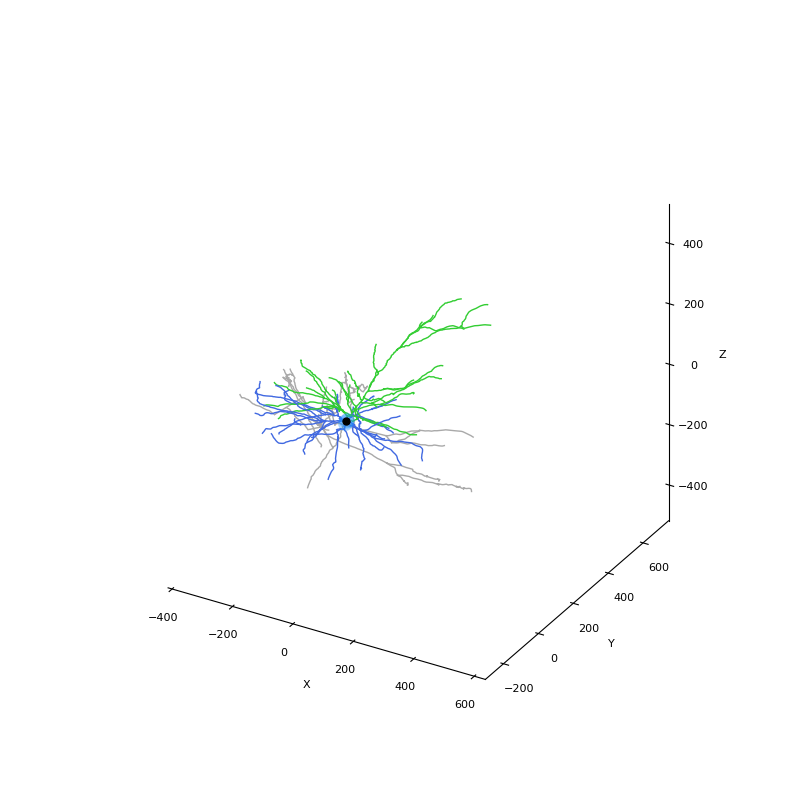

In [4]:
shell_cmd("swc view data/pass_nmo_1.swc -o output/nmo_1.png", image="output/nmo_1.png")

## Change The Projection

The same reconstruction can look different from another direction. Here, `-j xy` and `-j yz` choose two projection planes.

Executed command:
swc view data/pass_nmo_1.swc -j xy -o output/nmo_1_xy.png

Output:
(empty)


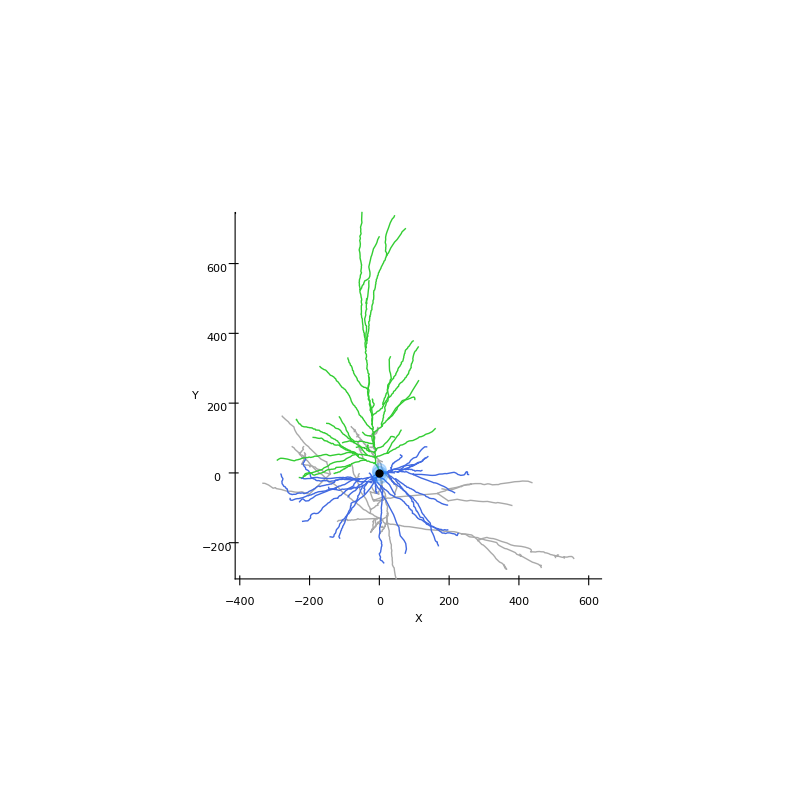

Executed command:
swc view data/pass_nmo_1.swc -j yz -o output/nmo_1_yz.png

Output:
(empty)


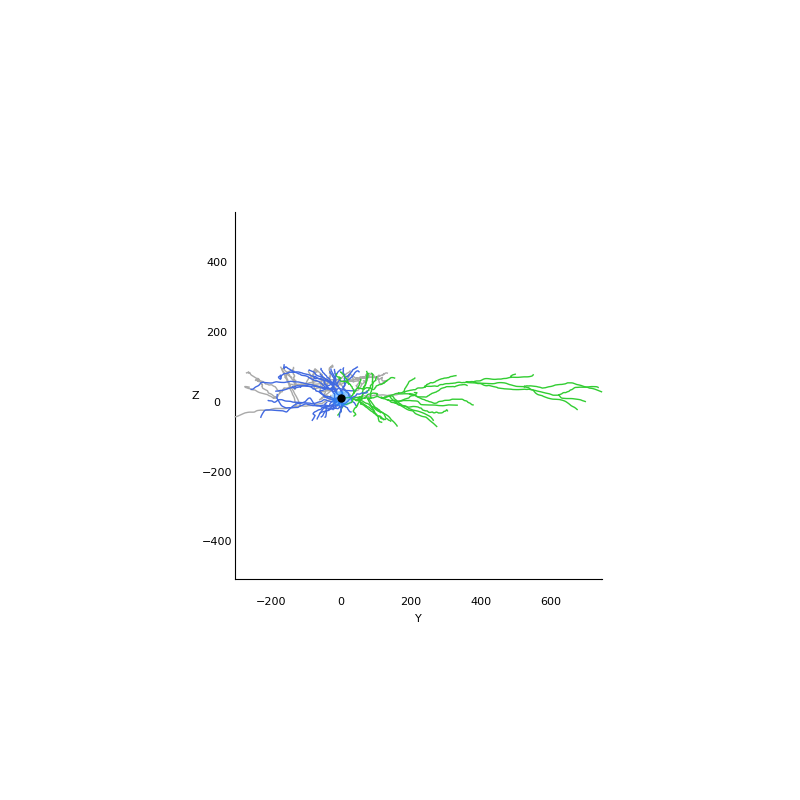

In [5]:
shell_cmd("swc view data/pass_nmo_1.swc -j xy -o output/nmo_1_xy.png", image="output/nmo_1_xy.png")
shell_cmd("swc view data/pass_nmo_1.swc -j yz -o output/nmo_1_yz.png", image="output/nmo_1_yz.png")

## Show and mark node IDs

Node IDs are useful when you need to point to a specific place in the reconstruction. Use `-m` to mark selected nodes and `--show-id` to show their labels.

Executed command:
swc view data/pass_simple_branch.swc -m 5 9 --show-id -o output/simple_branch_ids.png

Output:
(empty)


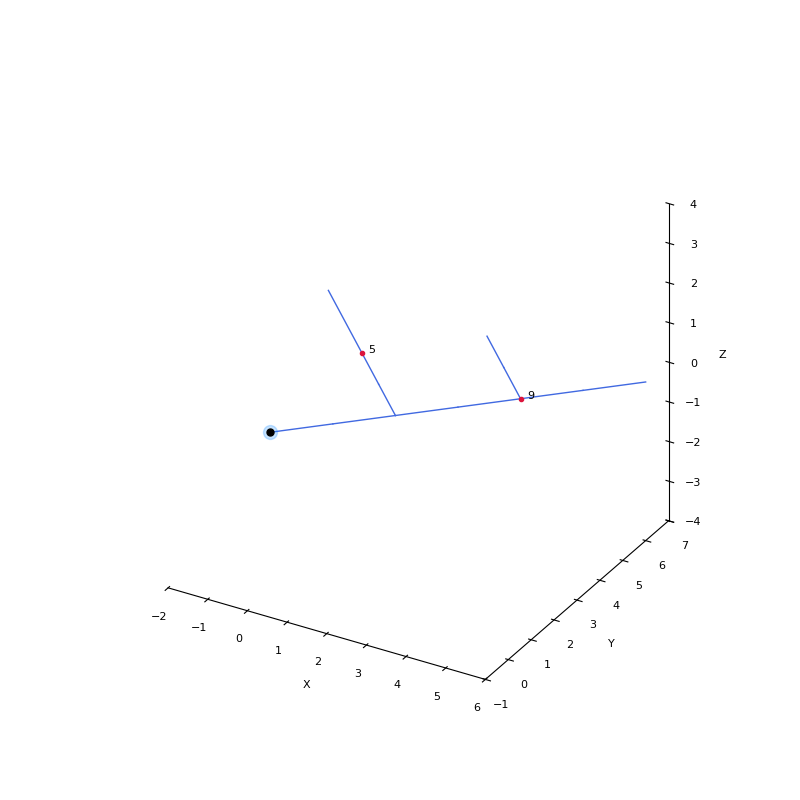

In [6]:
shell_cmd("swc view data/pass_simple_branch.swc -m 5 9 --show-id -o output/simple_branch_ids.png", image="output/simple_branch_ids.png")

## View several reconstructions together

Use `-c cells` when each reconstruction should have its own color. The filenames are kept in a short list so it is easy to add another file later.

Executed command:
swc view data/pass_mouselight_1.swc data/pass_mouselight_2.swc -c cells -o output/mouselight_cells.png

Output:
(empty)


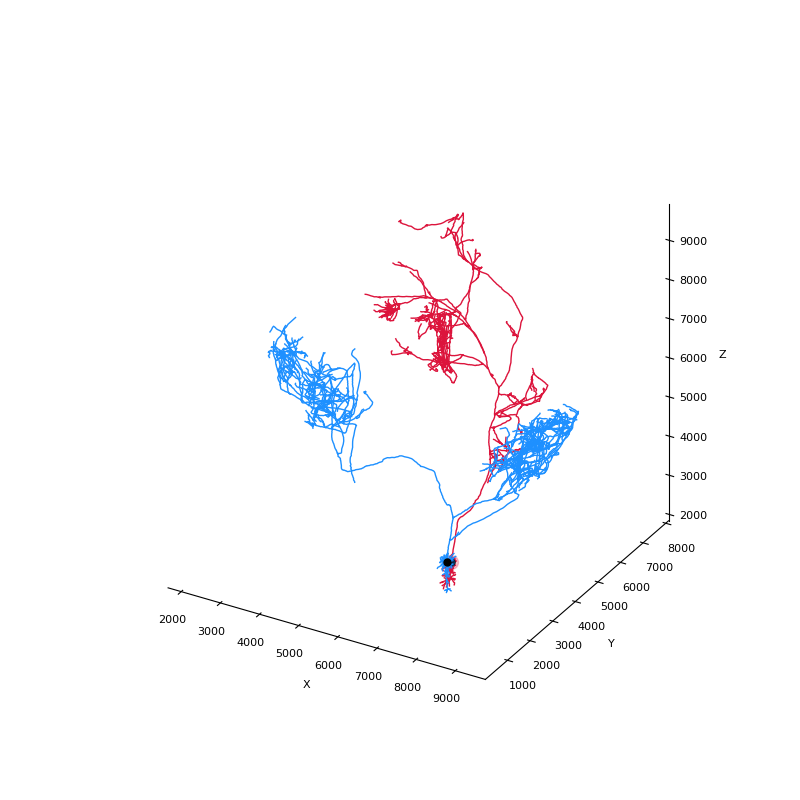

In [7]:
files = [
    "data/pass_mouselight_1.swc",
    "data/pass_mouselight_2.swc",
]
shell_cmd(
    f"swc view {' '.join(files)} -c cells -o output/mouselight_cells.png",
    image="output/mouselight_cells.png",
)

## Show selected point types

Use `-p` when you only want to show selected point types. Here, `-p 3` shows dendrite points (SWC point type `3` for basal dendrites).

Executed command:
swc view data/pass_nmo_1.swc -p 3 -o output/nmo_1_dendrites.png

Output:
(empty)


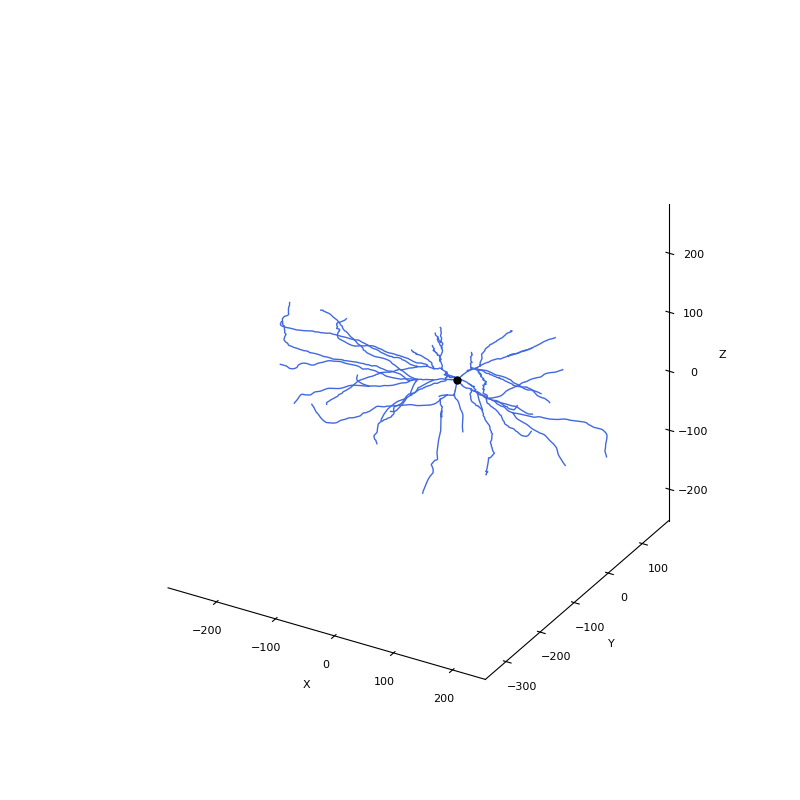

In [8]:
shell_cmd("swc view data/pass_nmo_1.swc -p 3 -o output/nmo_1_dendrites.png", image="output/nmo_1_dendrites.png")

## View terminal branch sections

Find terminal sections of basal dendrites, then show those branch sections in the reconstruction. Terminal sections have breadth `1`, and `--sec` returns section start IDs.

Executed command:
swc find data/pass_nmo_2_cut.swc -b 1 --sec -p 3

Output:
10 131 305 331 342 473 498 544 548 581 736 884 1000 1163
Executed command:
swc view data/pass_nmo_2_cut.swc -p 3 -b 10 131 305 331 342 473 498 544 548 581 736 884 1000 1163 -j xy --no-axes -o output/terminal_sections.png

Output:
(empty)


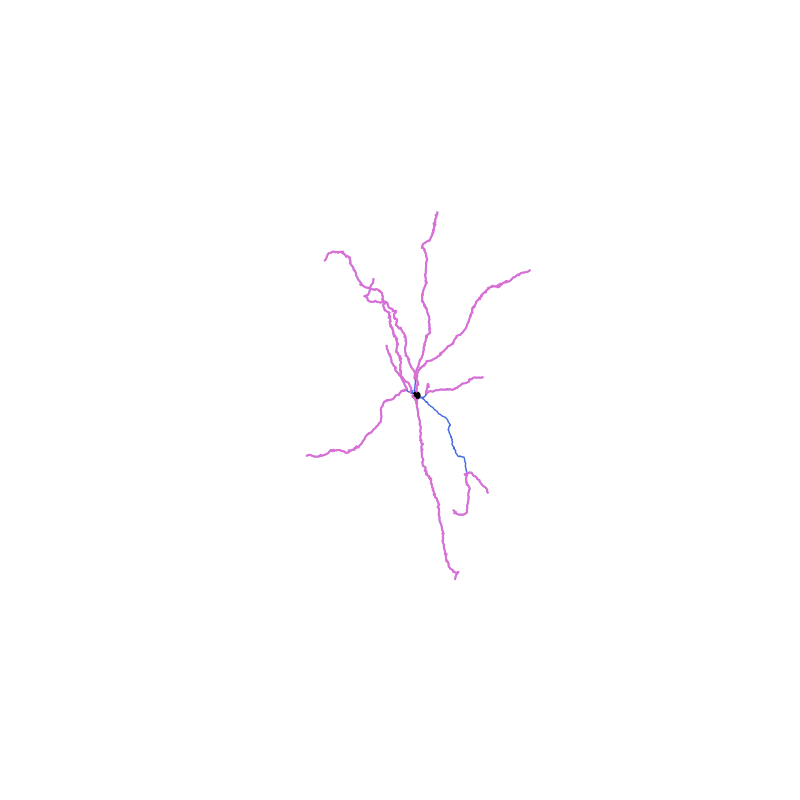

In [9]:
shell_cmd("swc find data/pass_nmo_2_cut.swc -b 1 --sec -p 3")
shell_cmd(
    "swc view data/pass_nmo_2_cut.swc -p 3 -b 10 131 305 331 342 473 498 544 548 581 736 884 1000 1163 -j xy --no-axes -o output/terminal_sections.png",
    image="output/terminal_sections.png",
)

## View the same branches as a dendrogram

Use `-g` to show the selected branch sections as a dendrogram.

Executed command:
swc view data/pass_nmo_2_cut.swc -p 3 -b 10 131 305 331 342 473 498 544 548 581 736 884 1000 1163 -j xy --no-axes -g -o output/terminal_sections_dendrogram.png

Output:
(empty)


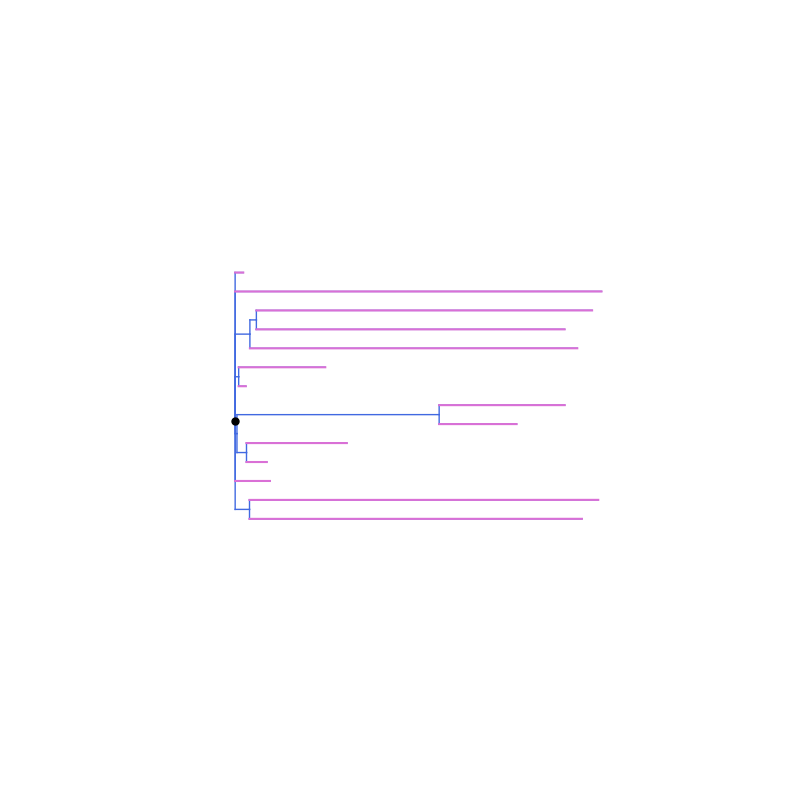

In [10]:
shell_cmd(
    "swc view data/pass_nmo_2_cut.swc -p 3 -b 10 131 305 331 342 473 498 544 548 581 736 884 1000 1163 -j xy --no-axes -g -o output/terminal_sections_dendrogram.png",
    image="output/terminal_sections_dendrogram.png",
)

## View the full reconstruction as a dendrogram

A dendrogram can also show the whole reconstruction.

Executed command:
swc view data/pass_nmo_2_cut.swc -g -j xy -o output/full_dendrogram.png

Output:
(empty)


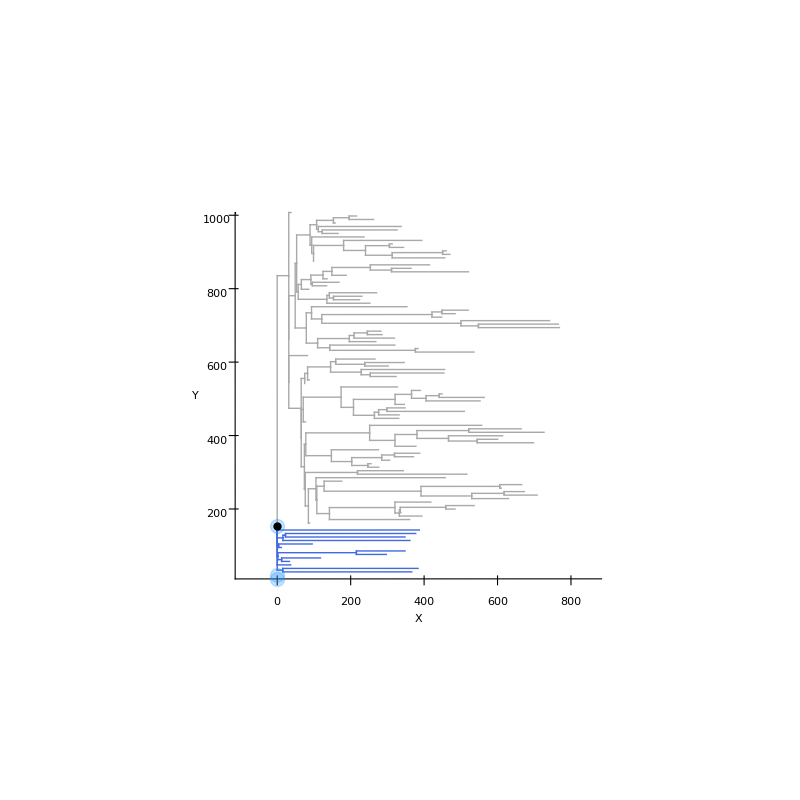

In [11]:
shell_cmd(
    "swc view data/pass_nmo_2_cut.swc -g -j xy -o output/full_dendrogram.png",
    image="output/full_dendrogram.png",
)

## Make a cleaner figure

For a figure, it is often useful to choose a projection, add a scale bar, hide the axes, and add a short title.

Executed command:
swc view data/pass_nmo_1.swc -j xy --scale 100 --no-axes -t "NMO reconstruction" -o output/nmo_1_clean.png

Output:
(empty)


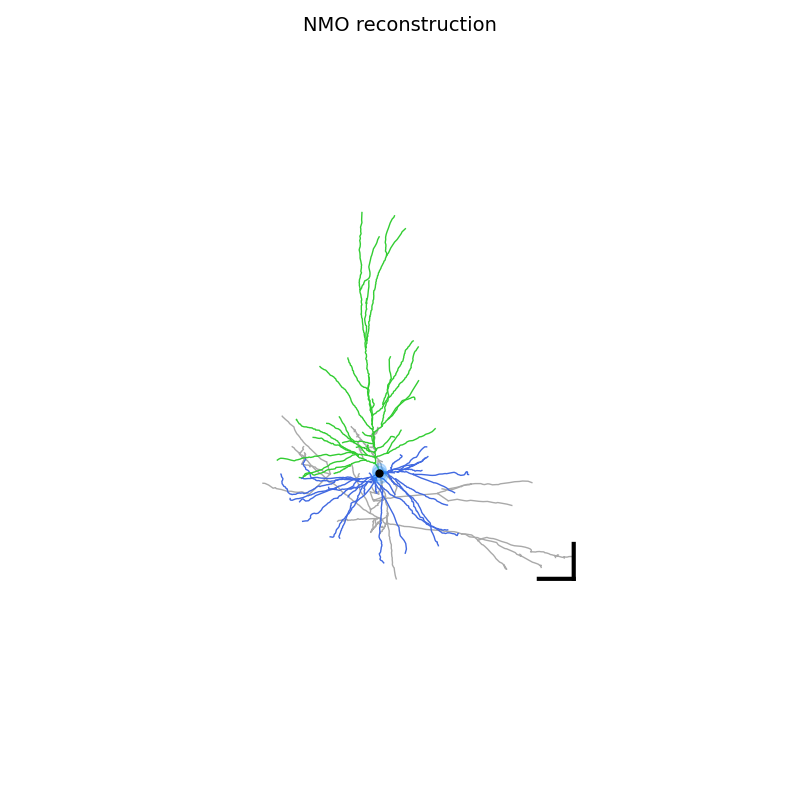

In [12]:
shell_cmd('swc view data/pass_nmo_1.swc -j xy --scale 100 --no-axes -t "NMO reconstruction" -o output/nmo_1_clean.png', 
          image="output/nmo_1_clean.png")

## Use shadow mode

Use `-c shadow` to compare multiple files while keeping the first reconstruction visually on top, painted with standard neurite colors.

Executed command:
swc view data/pass_mouselight_1.swc data/pass_mouselight_2.swc -c shadow -o output/mouselight_shadow.png

Output:
(empty)


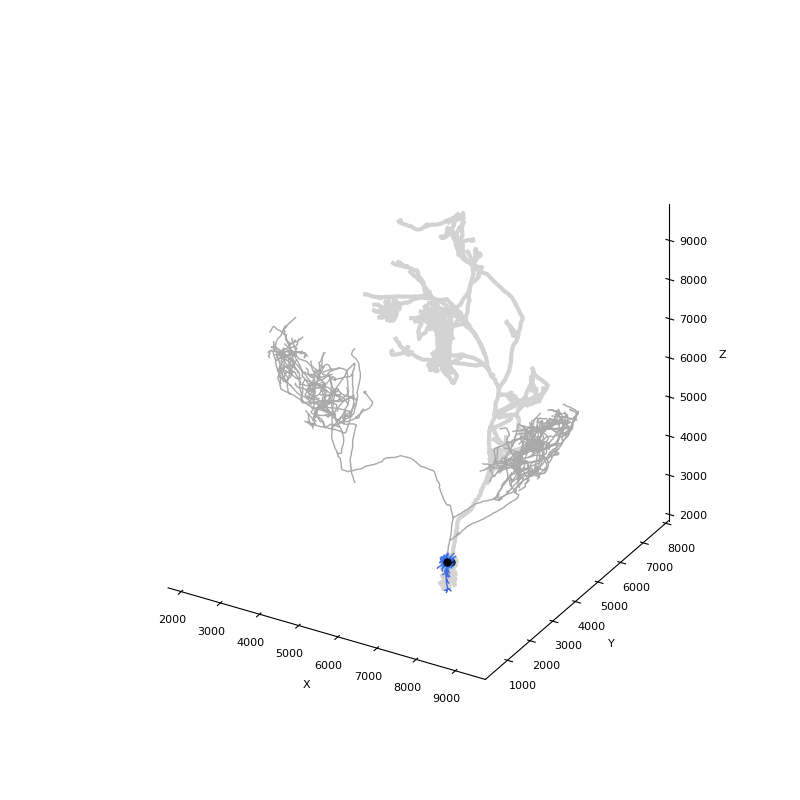

In [13]:
shell_cmd("swc view data/pass_mouselight_1.swc data/pass_mouselight_2.swc -c shadow -o output/mouselight_shadow.png", 
          image="output/mouselight_shadow.png")